In [1]:

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    f1_score
)

In [2]:
PROJECT_DIR = Path(
    r"C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\classifier\product\sterimol_circus_rev_1"
)

#TEST_DATA_FILE = PROJECT_DIR / (
    #r"Results\Selected_Data\RS42_consensus_n7_fast_aggr_False_test_data.parquet"
#)

TEST_DATA_FILE = PROJECT_DIR / (
    r"Data\molecular_descriptors_cleaned_exp_set_.parquet"
)

MODEL_FILE = PROJECT_DIR / (
    r"Results\Trained_Models\RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl"
)

OUTPUT_DIR = PROJECT_DIR / "Results" / "ReviewerValidation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Test data:", TEST_DATA_FILE)
print("Model:", MODEL_FILE)
print("Output:", OUTPUT_DIR)

Test data: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\classifier\product\sterimol_circus_rev_1\Data\molecular_descriptors_cleaned_exp_set_.parquet
Model: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\classifier\product\sterimol_circus_rev_1\Results\Trained_Models\RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl
Output: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\classifier\product\sterimol_circus_rev_1\Results\ReviewerValidation


In [3]:
assert TEST_DATA_FILE.exists(), f"Nie znaleziono: {TEST_DATA_FILE}"
assert MODEL_FILE.exists(), f"Nie znaleziono: {MODEL_FILE}"

print("OK — files found.")

OK — files found.


In [4]:
test_df = pd.read_parquet(TEST_DATA_FILE)
final_model = joblib.load(MODEL_FILE)

print("Test set shape:", test_df.shape)
display(test_df.head())

Test set shape: (36, 313)


,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,Sterimol_Alpha_R1_B1,Sterimol_Alpha_R1_B5,Alpha_Charge,...,CircuS_r1-3_ccn,CircuS_r1-3_cnc,CircuS_r1-3_O1[C@H](C(=O)c(c)n)C1,CircuS_r1-3_c1cc(nc1)C(=O)C,CircuS_r1-3_c1cc(C)nc1,CircuS_r1-3_c1ccnc1,CircuS_r1-3_cc(c)[C@H]1O[C@@H]1C(c(c)n)=O,CircuS_r1-3_C[C@H]1O[C@@H]1C(=O)c1cccn1,CircuS_r1-3_O1[C@H](C(=O)c2cccn2)C1,epox_cla
0,6.345000,1.7,7.413441,3.618626,1.7,2.062840,3.618626,1.7,2.062750,0.151587,...,0,0,0,0,0,0,0,0,0,1
1,5.748157,1.7,5.812713,3.614964,1.7,2.067437,3.614964,1.7,2.057653,0.151586,...,0,0,0,0,0,0,0,0,0,1
2,5.833553,1.7,5.772411,3.617124,1.7,2.068298,3.617124,1.7,2.058804,0.151585,...,0,0,0,0,0,0,0,0,0,1
3,8.964074,1.7,8.560327,3.616307,1.7,2.067219,3.616307,1.7,2.065829,0.151586,...,0,0,0,0,0,0,0,0,0,1
4,9.252596,1.7,9.590311,3.617116,1.7,2.067355,3.617116,1.7,2.058847,0.151543,...,0,0,0,0,0,0,0,0,0,1


In [5]:
test_df

,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,Sterimol_Beta_R2_B5,Sterimol_Alpha_R1_L,Sterimol_Alpha_R1_B1,Sterimol_Alpha_R1_B5,Alpha_Charge,...,CircuS_r1-3_ccn,CircuS_r1-3_cnc,CircuS_r1-3_O1[C@H](C(=O)c(c)n)C1,CircuS_r1-3_c1cc(nc1)C(=O)C,CircuS_r1-3_c1cc(C)nc1,CircuS_r1-3_c1ccnc1,CircuS_r1-3_cc(c)[C@H]1O[C@@H]1C(c(c)n)=O,CircuS_r1-3_C[C@H]1O[C@@H]1C(=O)c1cccn1,CircuS_r1-3_O1[C@H](C(=O)c2cccn2)C1,epox_cla
0,6.345000,1.7,7.413441,3.618626,1.7,2.062840,3.618626,1.7,2.062750,0.151587,...,0,0,0,0,0,0,0,0,0,1
1,5.748157,1.7,5.812713,3.614964,1.7,2.067437,3.614964,1.7,2.057653,0.151586,...,0,0,0,0,0,0,0,0,0,1
2,5.833553,1.7,5.772411,3.617124,1.7,2.068298,3.617124,1.7,2.058804,0.151585,...,0,0,0,0,0,0,0,0,0,1
3,8.964074,1.7,8.560327,3.616307,1.7,2.067219,3.616307,1.7,2.065829,0.151586,...,0,0,0,0,0,0,0,0,0,1
4,9.252596,1.7,9.590311,3.617116,1.7,2.067355,3.617116,1.7,2.058847,0.151543,...,0,0,0,0,0,0,0,0,0,1
5,7.010173,1.7,9.466606,3.616891,1.7,2.067078,3.616891,1.7,2.059231,0.151543,...,0,0,0,0,0,0,0,0,0,1
6,6.826598,1.7,7.259900,3.617337,1.7,2.067696,3.617337,1.7,2.057642,0.151543,...,0,0,0,0,0,0,0,0,0,1
7,6.410009,1.7,5.863253,3.621353,1.7,2.069617,3.621353,1.7,2.054616,0.151559,...,0,0,0,0,0,0,0,0,0,1
8,6.571835,1.7,6.451673,3.619607,1.7,2.063188,3.619607,1.7,2.063654,0.151572,...,0,0,0,0,0,0,0,0,0,0
9,6.940796,1.7,6.932701,3.616809,1.7,2.066939,3.616809,1.7,2.059429,0.151547,...,0,0,0,0,0,0,0,0,0,1


In [6]:
TARGET_COLUMN = "epox_cla"

In [7]:
display(test_df[[TARGET_COLUMN]].head(10))
assert test_df[TARGET_COLUMN].notna().all(), ()

,epox_cla
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,0
9,1


In [8]:
import joblib
print(final_model.named_steps.keys())


imputer = final_model.named_steps["imputer"]


FEATURE_COLUMNS_MODEL = list(imputer.feature_names_in_)


print("Number of features:", len(FEATURE_COLUMNS_MODEL))
#print("number of features test_df:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS_MODEL)

dict_keys(['imputer', 'scaler', 'model'])
Number of features: 6
['Sterimol_Beta_R2_B5', 'Sterimol_Alpha_R1_L', 'CircuS_r1-3_O1[C@@H](C)C1', 'CircuS_r1-3_ccc', 'CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C', 'CircuS_r1-3_[C@@H]1([C@H](C)O1)C']


In [9]:
FEATURE_COLUMNS = [
                               'Sterimol_Beta_R2_B5', 'Sterimol_Alpha_R1_L', 'CircuS_r1-3_O1[C@@H](C)C1', 'CircuS_r1-3_ccc', 'CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C', 'CircuS_r1-3_[C@@H]1([C@H](C)O1)C'
]



In [10]:
missing_features = [
    feature for feature in FEATURE_COLUMNS
    if feature not in test_df.columns
]

assert not missing_features, (
    f"Not found: {missing_features}"
)

In [11]:
# Podejrzyj kroki pipeline
print(final_model.named_steps.keys())

# Zwykle pierwszy krok, np. "imputer"
imputer = final_model.named_steps["imputer"]

# Kolejność cech zapamiętana podczas fit()
FEATURE_COLUMNS_MODEL = list(imputer.feature_names_in_)

# Diagnostyka
print("Liczba cech oczekiwana przez model:", len(FEATURE_COLUMNS_MODEL))
print("Liczba cech w test_df:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS_MODEL)

dict_keys(['imputer', 'scaler', 'model'])
Liczba cech oczekiwana przez model: 6
Liczba cech w test_df: 6
['Sterimol_Beta_R2_B5', 'Sterimol_Alpha_R1_L', 'CircuS_r1-3_O1[C@@H](C)C1', 'CircuS_r1-3_ccc', 'CircuS_r1-3_C[C@@H]1O[C@H]1C(=O)C', 'CircuS_r1-3_[C@@H]1([C@H](C)O1)C']


In [16]:
X_test = test_df[FEATURE_COLUMNS].copy()
y_true = test_df[TARGET_COLUMN].to_numpy(dtype=float)

y_pred = final_model.predict(X_test)

# Predicted probabilities for log-loss (binary classification)
if hasattr(final_model, "predict_proba"):
    y_proba_test = final_model.predict_proba(X_test)[:, 1]
else:
    y_proba_test = None

prospective_predictions = pd.DataFrame({
    "test_index": test_df.index.astype(str),
    "observed_ee": y_true,
    "final_model_prediction": y_pred,
})

display(prospective_predictions.round(2))

,test_index,observed_ee,final_model_prediction
0,0,1.0,1
1,1,1.0,1
2,2,1.0,1
3,3,1.0,1
4,4,1.0,1
5,5,1.0,1
6,6,1.0,1
7,7,1.0,1
8,8,0.0,1
9,9,1.0,1


In [17]:
def calculate_metrics_classification(y_true, y_pred, y_proba=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    if y_proba is not None:
        ll = log_loss(y_true, y_proba)
    else:
        ll = np.nan

    return {
        "Accuracy": acc,
        "Balanced_accuracy": bal_acc,
        "Log_loss": ll,
        "F1_macro": f1_macro,
    }


In [18]:
point_metrics = calculate_metrics_classification(y_true, y_pred, y_proba_test)
point_metrics_table = pd.DataFrame([point_metrics])
display(point_metrics_table.round(3))

,Accuracy,Balanced_accuracy,Log_loss,F1_macro
0,0.806,0.848,0.49,0.804


In [20]:
N_BOOTSTRAP = 10_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

n_test = len(y_true)
bootstrap_rows = []

for iteration in range(1, N_BOOTSTRAP + 1):
    sampled_indices = rng.integers(0, n_test, size=n_test)

    y_true_sample = y_true[sampled_indices]
    y_pred_sample = y_pred[sampled_indices]

    if y_proba_test is not None:
        y_proba_sample = y_proba_test[sampled_indices]
    else:
        y_proba_sample = None

    metrics = calculate_metrics_classification(
        y_true_sample,
        y_pred_sample,
        y_proba_sample
    )

    bootstrap_rows.append({
        "bootstrap_iteration": iteration,
        **metrics,
    })

bootstrap_metrics_raw = pd.DataFrame(bootstrap_rows)
display(bootstrap_metrics_raw.head())

,bootstrap_iteration,Accuracy,Balanced_accuracy,Log_loss,F1_macro
0,1,0.777778,0.840000,0.590932,0.771429
1,2,0.833333,0.875000,0.433860,0.828571
2,3,0.805556,0.865385,0.529653,0.792593
3,4,0.833333,0.875000,0.460359,0.828571
4,5,0.777778,0.818182,0.519590,0.777778


In [21]:
bootstrap_metrics_raw.to_excel("epox_cla_bootstrap.xlsx")

In [22]:

summary_rows = []

for metric_name in [
    "Accuracy",
    "Balanced_accuracy",
    "Log_loss",
    "F1_macro",
]:
    metric_values = bootstrap_metrics_raw[metric_name].dropna()

    summary_rows.append({
        "metric": metric_name,
        "point_estimate": point_metrics[metric_name],
        "bootstrap_median": metric_values.median(),
        "bootstrap_ci95_lower": metric_values.quantile(0.025),
        "bootstrap_ci95_upper": metric_values.quantile(0.975),
        "n_valid_bootstrap": len(metric_values),
        "n_total_bootstrap": N_BOOTSTRAP,
    })

bootstrap_metrics_summary = pd.DataFrame(summary_rows)
display(bootstrap_metrics_summary.round(3))


,metric,point_estimate,bootstrap_median,bootstrap_ci95_lower,bootstrap_ci95_upper,n_valid_bootstrap,n_total_bootstrap
0,Accuracy,0.806,0.806,0.667,0.917,10000,10000
1,Balanced_accuracy,0.848,0.850,0.750,0.938,10000,10000
2,Log_loss,0.490,0.481,0.309,0.718,10000,10000
3,F1_macro,0.804,0.804,0.662,0.917,10000,10000


In [23]:
bootstrap_metrics_summary.to_excel('bootstrap_exp_set.xlsx')

Saved SVG: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\classifier\product\sterimol_circus_rev_1\QSPR\bootstrap_classification_metrics.svg


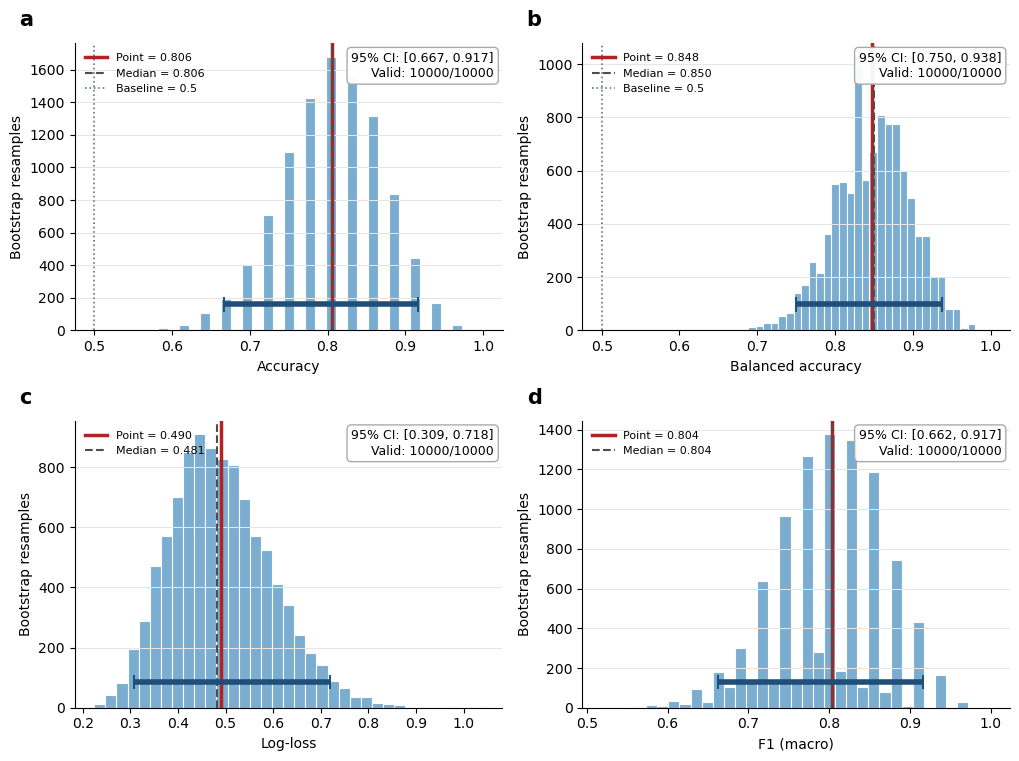

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_FILE = Path("bootstrap_classification_metrics.svg")

COLORS = {
    "histogram": "#74A9CF",
    "point": "#B22222",
    "median": "#4D4D4D",
    "ci": "#1F4E79",
    "zero": "#6C757D",
    "grid": "#E6E6E6",
}

metrics_config = [
    ("Accuracy", "Accuracy", "a"),
    ("Balanced_accuracy", "Balanced accuracy", "b"),
    ("Log_loss", "Log-loss", "c"),
    ("F1_macro", "F1 (macro)", "d"),
]

summary_lookup = bootstrap_metrics_summary.set_index("metric")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.3, 7.7),
)

for ax, (metric, xlabel, panel) in zip(axes.ravel(), metrics_config):

    values = pd.to_numeric(
        bootstrap_metrics_raw[metric],
        errors="coerce",
    ).dropna()

    summary = summary_lookup.loc[metric]

    point_estimate = float(summary["point_estimate"])
    median = float(summary["bootstrap_median"])
    ci_low = float(summary["bootstrap_ci95_lower"])
    ci_high = float(summary["bootstrap_ci95_upper"])
    n_valid = int(summary["n_valid_bootstrap"])
    n_total = int(summary["n_total_bootstrap"])

    ax.hist(
        values,
        bins=35,
        color=COLORS["histogram"],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95,
    )

    ax.axvline(
        point_estimate,
        color=COLORS["point"],
        linewidth=2.5,
        label=f"Point = {point_estimate:.3f}",
    )

    ax.axvline(
        median,
        color=COLORS["median"],
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {median:.3f}",
    )

    # Baseline for accuracy & balanced accuracy
    if metric in {"Accuracy", "Balanced_accuracy"}:
        ax.axvline(
            0.5,
            color=COLORS["zero"],
            linestyle=":",
            linewidth=1.2,
            label="Baseline = 0.5",
        )

    ymax = ax.get_ylim()[1]
    y_ci = ymax * 0.09

    ax.hlines(
        y_ci,
        ci_low,
        ci_high,
        color=COLORS["ci"],
        linewidth=4,
    )

    ax.vlines(
        [ci_low, ci_high],
        y_ci * 0.72,
        y_ci * 1.28,
        color=COLORS["ci"],
        linewidth=1.4,
    )

    ax.text(
        -0.13,
        1.06,
        panel,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
    )

    ax.text(
        0.98,
        0.97,
        (
            f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]\n"
            f"Valid: {n_valid}/{n_total}"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#A6A6A6",
            alpha=0.95,
        ),
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Bootstrap resamples")

    ax.yaxis.grid(True, color=COLORS["grid"], linewidth=0.75)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, fontsize=8, loc="upper left")

fig.tight_layout()

fig.savefig(
    OUTPUT_FILE,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
)

print(f"Saved SVG: {OUTPUT_FILE.resolve()}")

plt.show()